In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

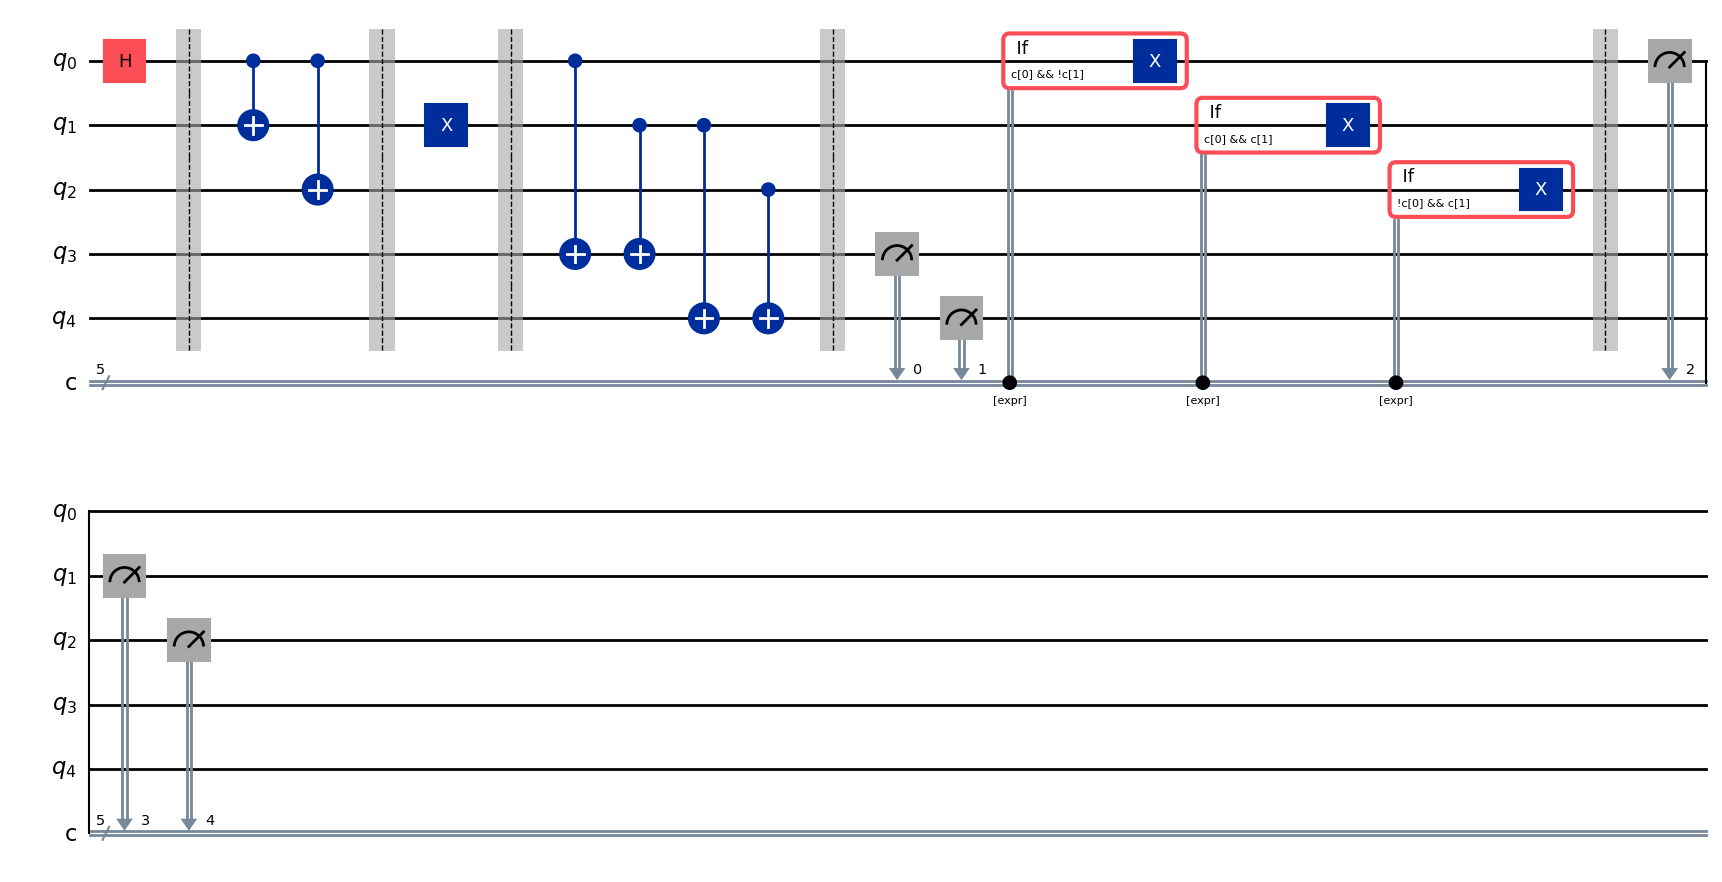

In [2]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit bit-flip error-correcting code

flip = QuantumCircuit(5,5)

# qubit 0 is the one we are trying to send
# qubits 1 and 2 are used for the encoding
# qubits 3 and 4 are used for the error syndrome
# classical bits 0 and 1 are used for the syndrome measurement
# classical bits 2, 3 and 4 are for a final measurement to check the statistics

# Put qubit 0 into the |+> state. As we discussed in the lecture, this isn't a good
# state for testing the bit-flip code, because bit-flip doesn't change the |+> state.
# Try putting qubit 0 into some other state that is affected by bit-flip.
# There is a suggestion in the lecture.
flip.h(0)

# Introduce barriers to help with visualisation

flip.barrier()

# Encode qubit 0 onto qubits 1 and 2

flip.cx(0,1)
flip.cx(0,2)

# Another barrier

flip.barrier()

# Add a bit-flip error
# Try errors on the other qubits, and check that the code corrects any single bit flip error.
# What happens if you flip two qubits?
# What happens if you introduce a phase flip error?

flip.x(1)

# Another barrier

flip.barrier()

# Syndrome measurements

flip.cx(0,3)
flip.cx(1,3)
flip.cx(1,4)
flip.cx(2,4)

flip.barrier()

flip.measure([3,4],[0,1])

# Conditional application of X to qubits 0, 1 and 2
# if c0 and not c1 then X(q0)
# if c0 and c1 then X(q1)
# if not c0 and c1 then X(q2)

with flip.if_test(expr.logic_and(flip.clbits[0],expr.logic_not(flip.clbits[1]))):
    flip.x(0)

with flip.if_test(expr.logic_and(flip.clbits[0],flip.clbits[1])):
    flip.x(1)

with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]),flip.clbits[1])):
    flip.x(2)

flip.barrier()

# The original state of qubit 0 was encoded by being "spread" across qubits 1 and 2.
# We are now back in that encoded state.
# Because of the entanglement, measuring qubits 0, 1 and 2
# should give the same statistics as measuring the original qubit 0.

# You can also implement the final decoding, putting the state back into a single qubit, and measuring it.

flip.measure([0,1,2],[2,3,4])

# Check the circuit

flip.draw("mpl")


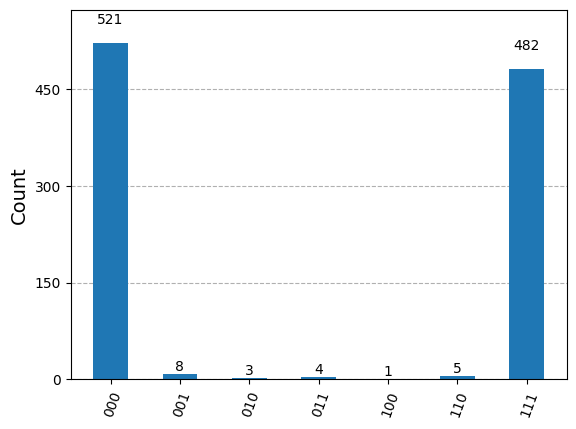

In [3]:
# Simulate and plot results
# Use GenericBackendV2 because we need if_test

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)

In [4]:
# create the full error-correction circuit
def build_bitflip_code(error_ops=None, prepare="0", decode=False, measure_basis="Z"):
    if error_ops is None:
        error_ops = []

    flip = QuantumCircuit(5, 5)

    # Prepare q0
    if prepare == "0":
        pass
    elif prepare == "1":
        flip.x(0)
    elif prepare == "+":
        flip.h(0)
    elif prepare == "-":
        flip.x(0)
        flip.h(0)
    else:
        raise ValueError("prepare must be one of: '0', '1', '+', '-'")

    flip.barrier()

    # Encode q0 into q0,q1,q2
    flip.cx(0, 1)
    flip.cx(0, 2)

    flip.barrier()

    # Inject errors
    for gate_name, qubit in error_ops:
        getattr(flip, gate_name)(qubit)

    flip.barrier()

    # Syndrome extraction
    flip.cx(0, 3)
    flip.cx(1, 3)
    flip.cx(1, 4)
    flip.cx(2, 4)

    flip.barrier()

    flip.measure([3, 4], [0, 1])

    # Conditional correction
    with flip.if_test(expr.logic_and(flip.clbits[0], expr.logic_not(flip.clbits[1]))):
        flip.x(0)

    with flip.if_test(expr.logic_and(flip.clbits[0], flip.clbits[1])):
        flip.x(1)

    with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]), flip.clbits[1])):
        flip.x(2)

    flip.barrier()

    if decode:
        # Decode back to q0
        flip.cx(0, 2)
        flip.cx(0, 1)

        # Choose measurement basis for q0
        if measure_basis == "X":
            flip.h(0)
        elif measure_basis != "Z":
            raise ValueError("measure_basis must be 'Z' or 'X'")

        flip.measure(0, 2)
    else:
        flip.measure([0, 1, 2], [2, 3, 4])

    return flip

In [5]:
# execute the circuit and display what happened.
def run_and_show(error_ops=None, prepare="0", decode=False, measure_basis="Z", shots=1024):
    backend = GenericBackendV2(num_qubits=5, control_flow=True)
    circ = build_bitflip_code(
        error_ops=error_ops,
        prepare=prepare,
        decode=decode,
        measure_basis=measure_basis
    )
    compiled = transpile(circ, backend)
    result = backend.run(compiled, shots=shots).result()
    counts = result.get_counts(compiled)

    print("Full counts:")
    print(counts)

    syndrome_counts = marginal_counts(counts, indices=[0, 1])
    print("\nSyndrome counts:")
    print(syndrome_counts)
    display(plot_histogram(syndrome_counts))

    if decode:
        out_counts = marginal_counts(counts, indices=[2])
        print(f"\nDecoded q0 counts in {measure_basis} basis:")
        print(out_counts)
        display(plot_histogram(out_counts))
    else:
        out_counts = marginal_counts(counts, indices=[2, 3, 4])
        print("\nEncoded data qubit counts:")
        print(out_counts)
        display(plot_histogram(out_counts))

    return circ

Bit-flip correction check


=== Check 1: No error, starting from |0> ===
Full counts:
{'01000': 1, '00101': 3, '10010': 1, '00100': 1, '10000': 9, '00000': 1009}

Syndrome counts:
{'00': 1020, '01': 3, '10': 1}


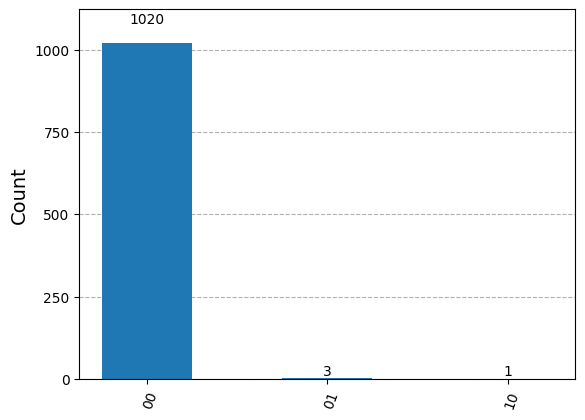


Encoded data qubit counts:
{'010': 1, '001': 4, '100': 10, '000': 1009}


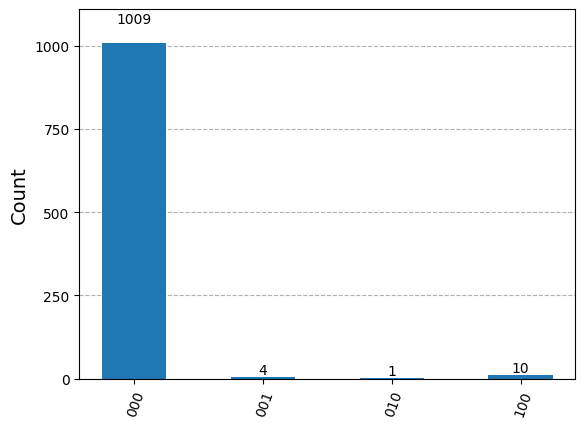


=== Check 2: Bit-flip error on q0, starting from |0> ===
Full counts:
{'10001': 1, '00101': 6, '01101': 1, '01001': 5, '00100': 14, '00001': 997}

Syndrome counts:
{'01': 1010, '00': 14}


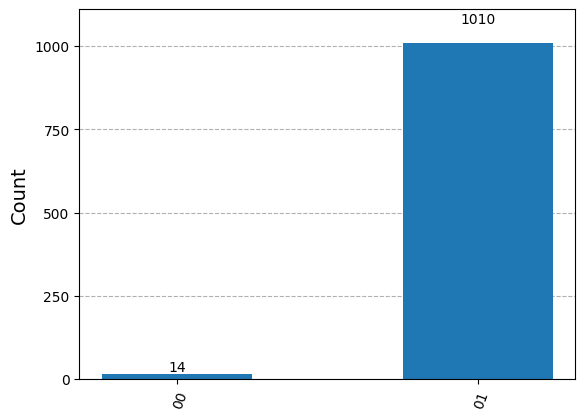


Encoded data qubit counts:
{'100': 1, '001': 20, '011': 1, '010': 5, '000': 997}


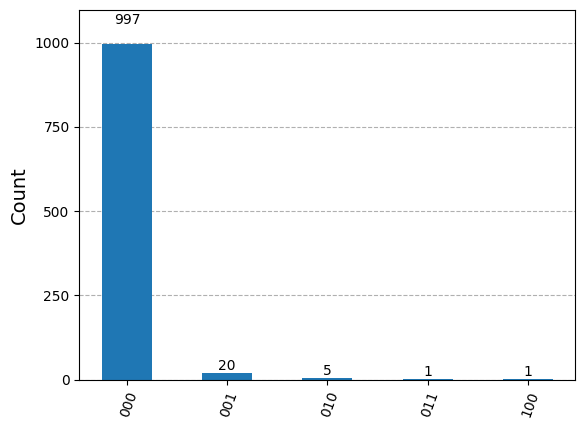


=== Check 3: Bit-flip error on q1, starting from |0> ===
Full counts:
{'01101': 11, '11010': 5, '00101': 6, '00111': 3, '01011': 13, '00011': 986}

Syndrome counts:
{'01': 17, '10': 5, '11': 1002}


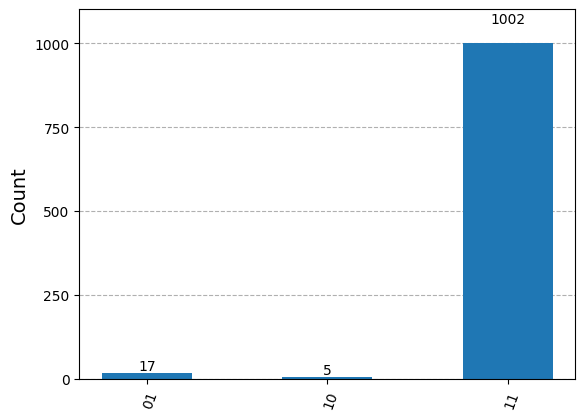


Encoded data qubit counts:
{'011': 11, '110': 5, '001': 9, '010': 13, '000': 986}


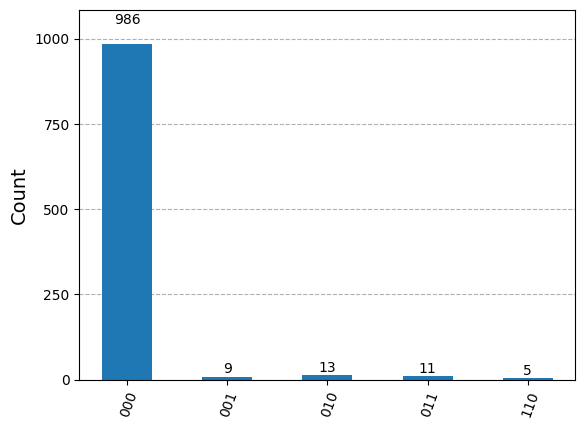


=== Check 4: Bit-flip error on q2, starting from |0> ===
Full counts:
{'11011': 1, '01010': 3, '00110': 5, '10000': 6, '10010': 10, '00000': 1, '00010': 998}

Syndrome counts:
{'11': 1, '10': 1016, '00': 7}


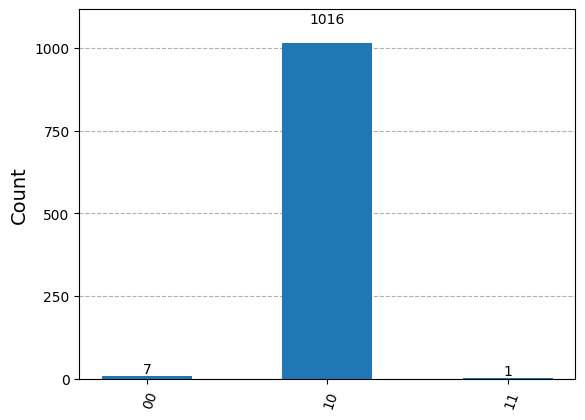


Encoded data qubit counts:
{'110': 1, '010': 3, '001': 5, '100': 16, '000': 999}


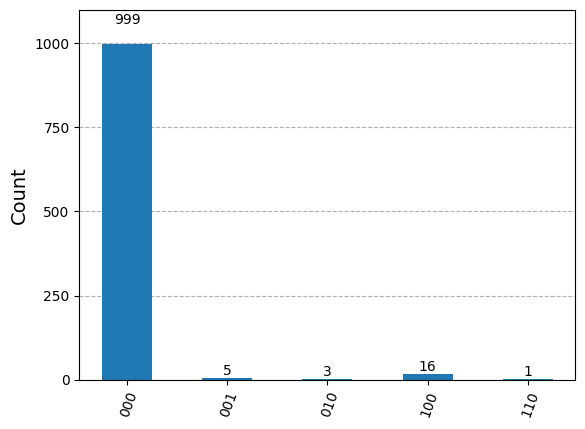

In [6]:
print("\n=== Check 1: No error, starting from |0> ===")
run_and_show(error_ops=[], prepare="0")

print("\n=== Check 2: Bit-flip error on q0, starting from |0> ===")
run_and_show(error_ops=[("x", 0)], prepare="0")

print("\n=== Check 3: Bit-flip error on q1, starting from |0> ===")
run_and_show(error_ops=[("x", 1)], prepare="0")

print("\n=== Check 4: Bit-flip error on q2, starting from |0> ===")
run_and_show(error_ops=[("x", 2)], prepare="0")


=== Check 5: Double bit-flip errors on q0 and q1, starting from |0> ===
Full counts:
{'01100': 1, '11010': 3, '00011': 1, '00111': 12, '00100': 6, '10110': 4, '11100': 1, '00001': 1, '00010': 2, '11110': 993}

Syndrome counts:
{'00': 8, '10': 1002, '11': 13, '01': 1}


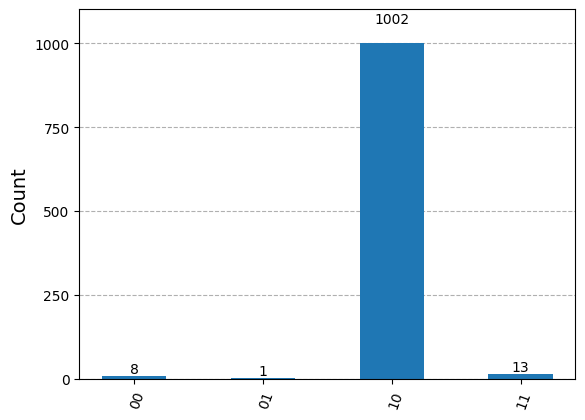


Encoded data qubit counts:
{'011': 1, '110': 3, '000': 4, '001': 18, '101': 4, '111': 994}


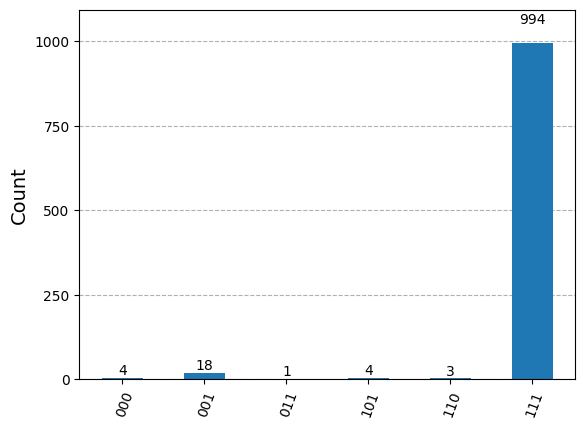


=== Check 6: Double bit-flip errors on q0 and q2, starting from |0> ===
Full counts:
{'00110': 2, '10111': 3, '11001': 1, '11011': 9, '10001': 9, '00001': 1, '01111': 8, '11111': 991}

Syndrome counts:
{'10': 2, '11': 1011, '01': 11}


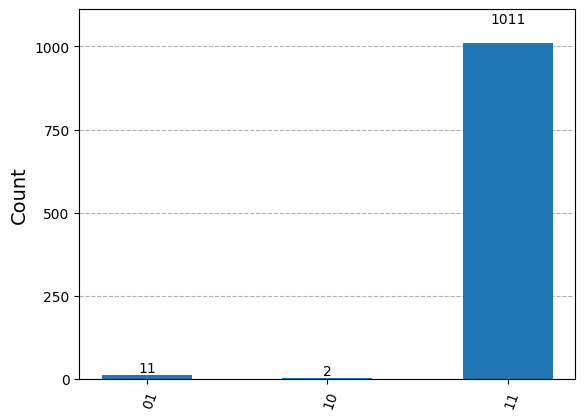


Encoded data qubit counts:
{'001': 2, '101': 3, '110': 10, '100': 9, '000': 1, '011': 8, '111': 991}


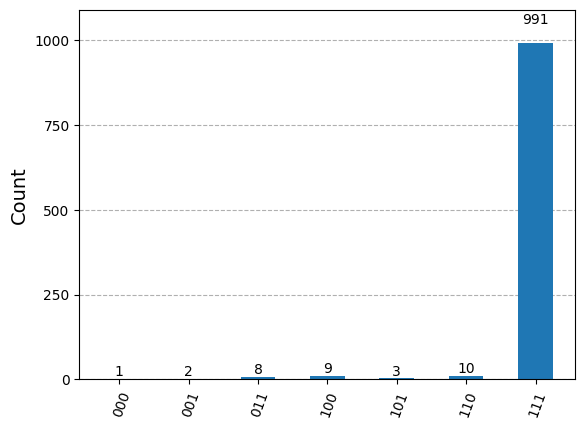


=== Check 7: Double bit-flip errors on q1 and q2, starting from |0> ===
Full counts:
{'01101': 5, '01010': 1, '11001': 4, '11011': 4, '11000': 10, '10011': 9, '10101': 3, '11101': 988}

Syndrome counts:
{'01': 1000, '10': 1, '11': 13, '00': 10}


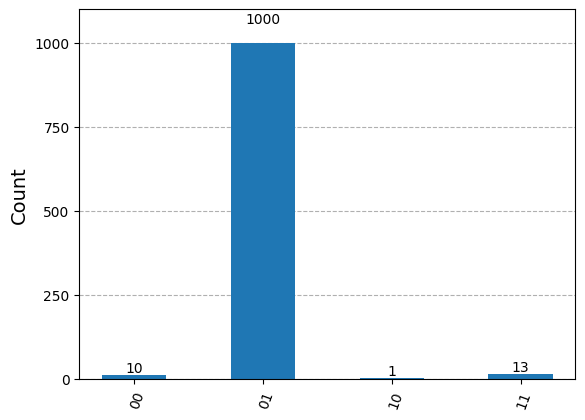


Encoded data qubit counts:
{'011': 5, '010': 1, '110': 18, '100': 9, '101': 3, '111': 988}


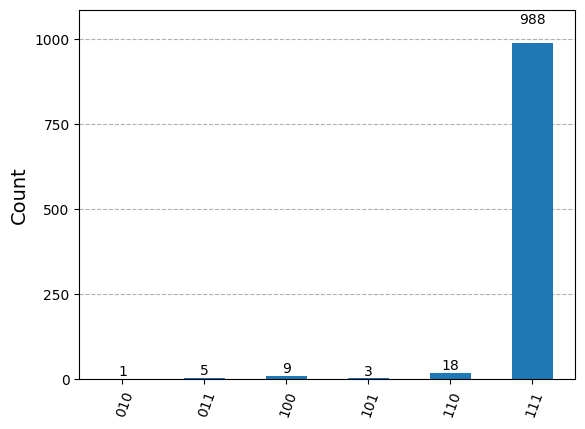

In [7]:
print("\n=== Check 5: Double bit-flip errors on q0 and q1, starting from |0> ===")
run_and_show(error_ops=[("x", 0), ("x", 1)], prepare="0")

print("\n=== Check 6: Double bit-flip errors on q0 and q2, starting from |0> ===")
run_and_show(error_ops=[("x", 0), ("x", 2)], prepare="0")

print("\n=== Check 7: Double bit-flip errors on q1 and q2, starting from |0> ===")
run_and_show(error_ops=[("x", 1), ("x", 2)], prepare="0")


=== Check 8: Phase-flip error on q0, starting from |+>, decode and measure in X basis ===
Full counts:
{'00011': 2, '00110': 8, '00101': 2, '00010': 4, '00000': 12, '00100': 996}

Syndrome counts:
{'11': 2, '10': 12, '01': 2, '00': 1008}


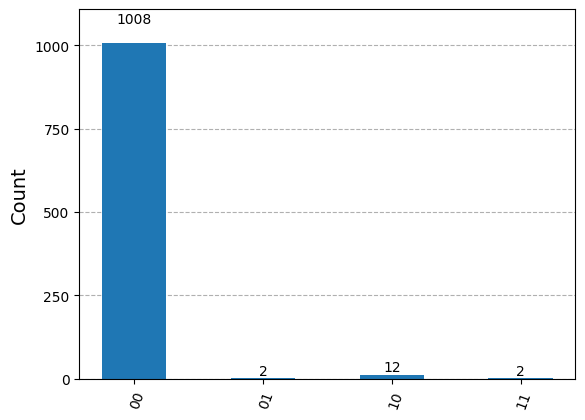


Decoded q0 counts in X basis:
{'0': 18, '1': 1006}


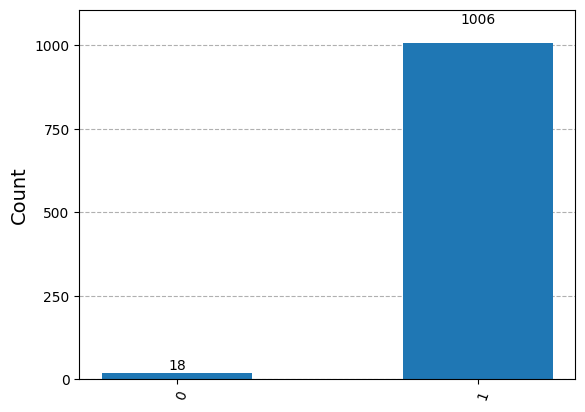


=== Check 9: Phase-flip error on q1, starting from |+>, decode and measure in X basis ===
Full counts:
{'00101': 1, '00110': 5, '00001': 1, '00011': 6, '00111': 6, '00010': 6, '00000': 19, '00100': 980}

Syndrome counts:
{'01': 2, '10': 11, '11': 12, '00': 999}


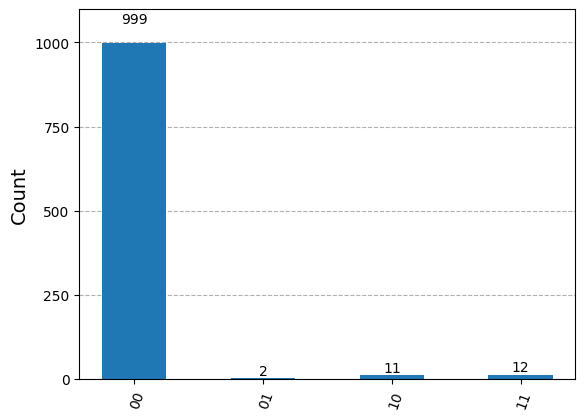


Decoded q0 counts in X basis:
{'1': 992, '0': 32}


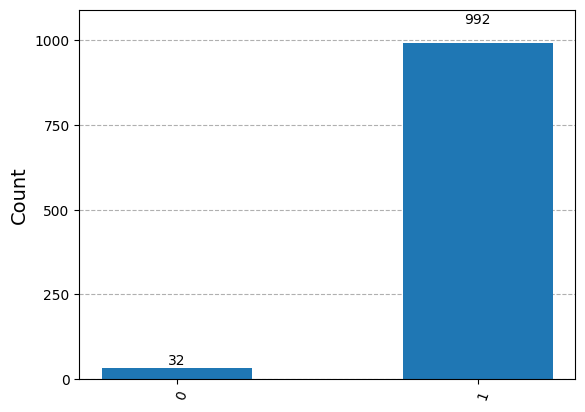


=== Check 10: Phase-flip error on q2, starting from |+>, decode and measure in X basis ===
Full counts:
{'00001': 1, '00011': 4, '00111': 5, '00010': 3, '00000': 20, '00110': 10, '00100': 981}

Syndrome counts:
{'01': 1, '11': 9, '10': 13, '00': 1001}


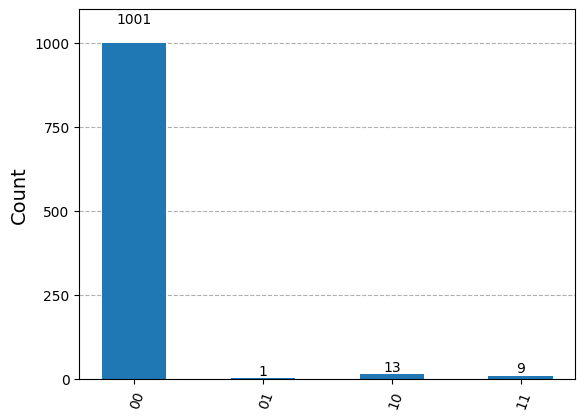


Decoded q0 counts in X basis:
{'0': 28, '1': 996}


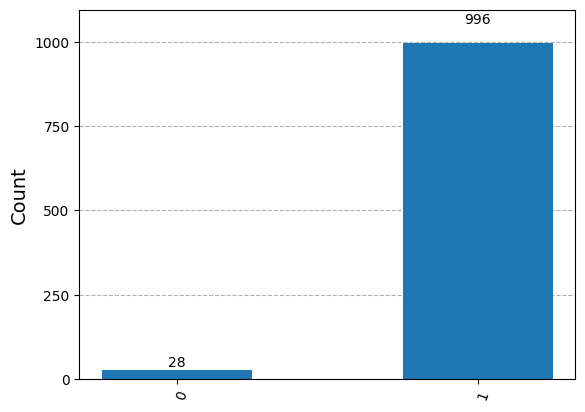

In [8]:
print("\n=== Check 8: Phase-flip error on q0, starting from |+>, decode and measure in X basis ===")
run_and_show(error_ops=[("z", 0)], prepare="+", decode=True, measure_basis="X")

print("\n=== Check 9: Phase-flip error on q1, starting from |+>, decode and measure in X basis ===")
run_and_show(error_ops=[("z", 1)], prepare="+", decode=True, measure_basis="X")

print("\n=== Check 10: Phase-flip error on q2, starting from |+>, decode and measure in X basis ===")
run_and_show(error_ops=[("z", 2)], prepare="+", decode=True, measure_basis="X")


=== Check 11: No error, starting from |+>, decode and measure in X basis ===
Full counts:
{'00101': 2, '00001': 7, '00110': 6, '00111': 4, '00011': 3, '00100': 8, '00010': 7, '00000': 987}

Syndrome counts:
{'01': 9, '10': 13, '11': 7, '00': 995}


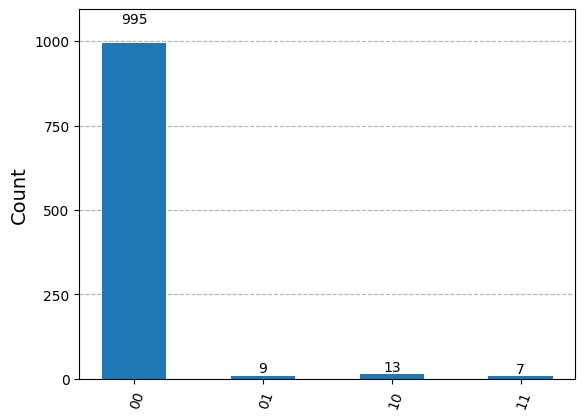


Decoded q0 counts in X basis:
{'1': 20, '0': 1004}


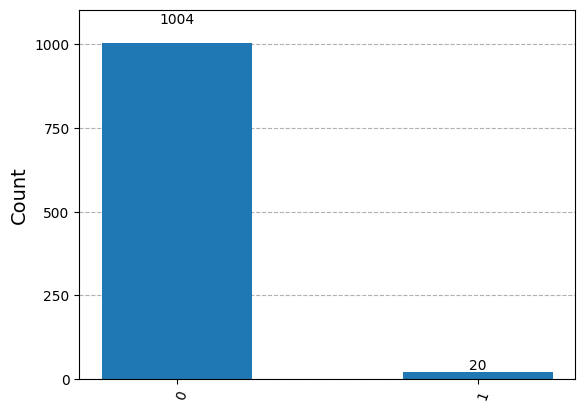

In [9]:
print("\n=== Check 11: No error, starting from |+>, decode and measure in X basis ===")
run_and_show(error_ops=[], prepare="+", decode=True, measure_basis="X")

Does it preserves `111`?


=== Check 12: No error, starting from |1> ===
Full counts:
{'00110': 2, '01100': 5, '11010': 1, '11000': 4, '00010': 1, '00000': 1, '01110': 5, '11110': 2, '11001': 13, '01011': 1, '00011': 5, '10100': 5, '11100': 979}

Syndrome counts:
{'10': 11, '00': 994, '01': 13, '11': 6}


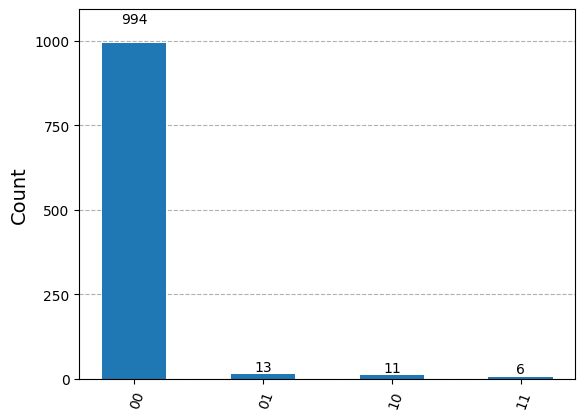


Encoded data qubit counts:
{'001': 2, '011': 10, '110': 18, '000': 7, '111': 981, '010': 1, '101': 5}


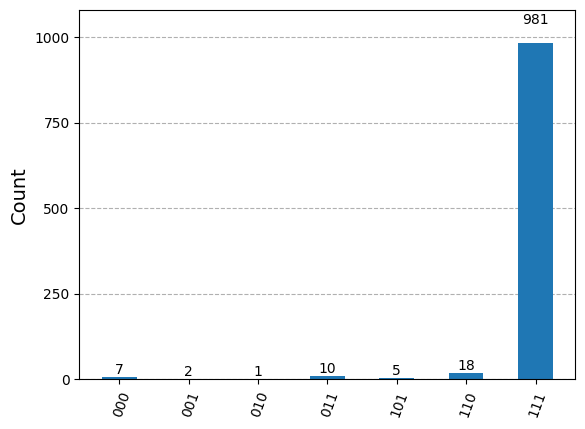


=== Check 13: Bit-flip error on q0, starting from |1> ===
Full counts:
{'00010': 1, '01101': 2, '11100': 1, '11000': 9, '11110': 3, '10011': 6, '11011': 1, '11001': 2, '00011': 3, '10101': 6, '11101': 990}

Syndrome counts:
{'10': 4, '01': 1000, '00': 10, '11': 10}


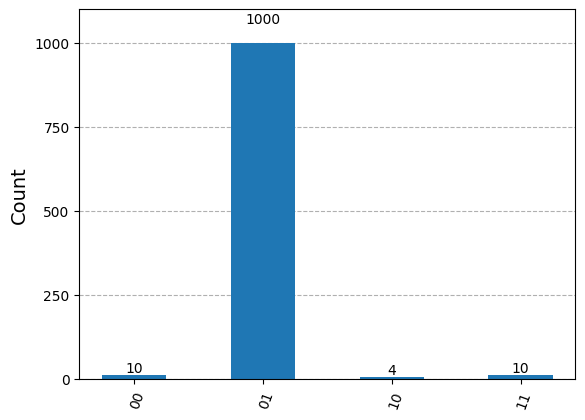


Encoded data qubit counts:
{'000': 4, '011': 2, '111': 994, '110': 12, '100': 6, '101': 6}


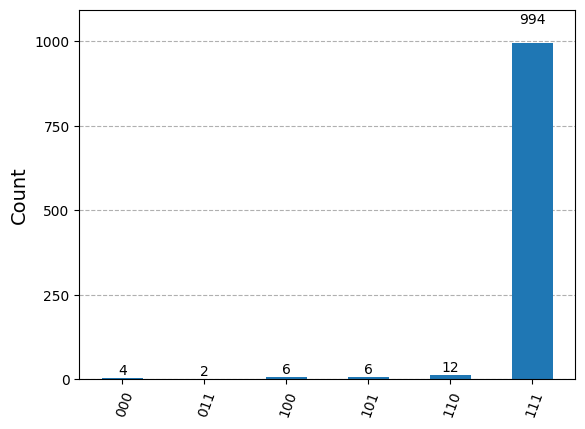


=== Check 14: Bit-flip error on q1, starting from |1> ===
Full counts:
{'10001': 2, '11011': 2, '01111': 2, '00001': 1, '11100': 4, '00000': 3, '10111': 2, '00010': 4, '00110': 18, '11111': 986}

Syndrome counts:
{'01': 3, '11': 992, '00': 7, '10': 22}


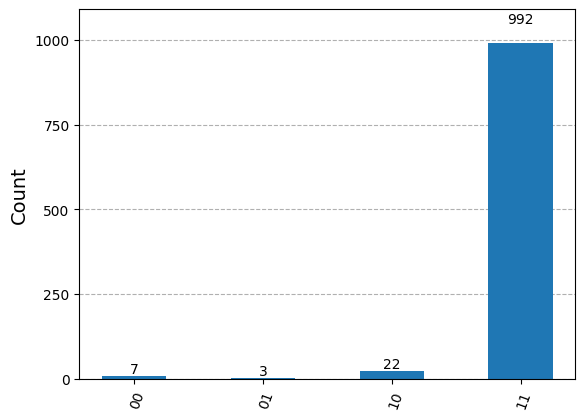


Encoded data qubit counts:
{'100': 2, '110': 2, '011': 2, '000': 8, '111': 990, '101': 2, '001': 18}


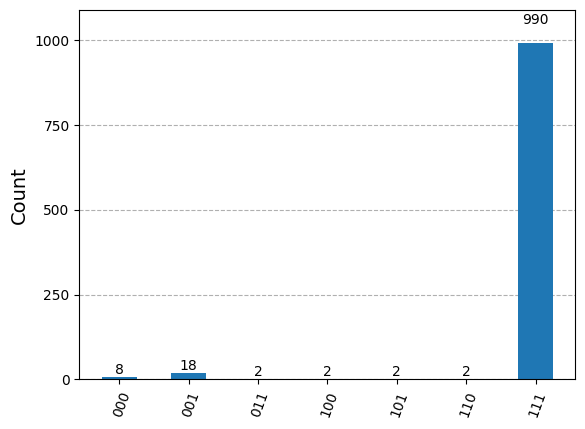


=== Check 15: Bit-flip error on q2, starting from |1> ===
Full counts:
{'11010': 3, '01110': 4, '00100': 5, '01000': 1, '01100': 15, '00111': 5, '00011': 1, '11101': 8, '11110': 970, '11100': 4, '00001': 2, '10110': 6}

Syndrome counts:
{'10': 983, '00': 25, '11': 6, '01': 10}


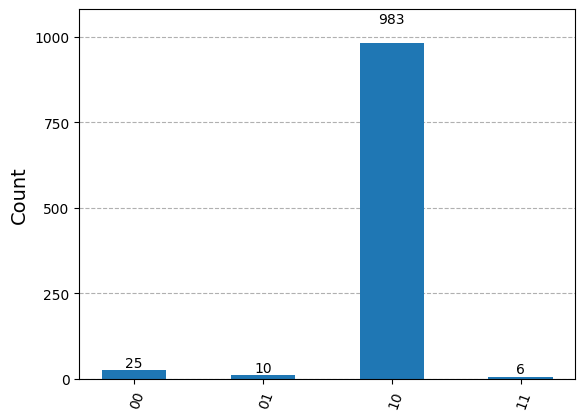


Encoded data qubit counts:
{'110': 3, '011': 19, '001': 10, '010': 1, '000': 3, '111': 982, '101': 6}


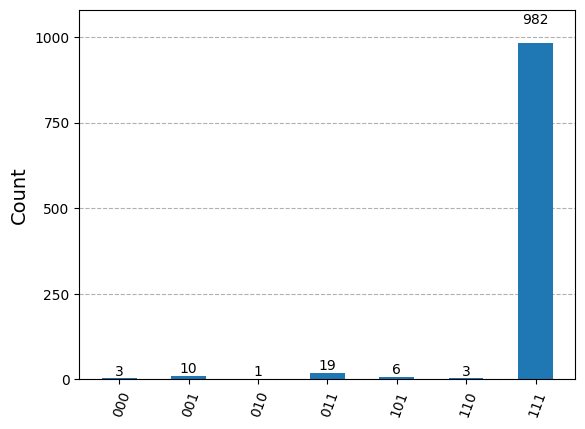

In [10]:
print("\n=== Check 12: No error, starting from |1> ===")
run_and_show(error_ops=[], prepare="1")

print("\n=== Check 13: Bit-flip error on q0, starting from |1> ===")
run_and_show(error_ops=[("x", 0)], prepare="1")

print("\n=== Check 14: Bit-flip error on q1, starting from |1> ===")
run_and_show(error_ops=[("x", 1)], prepare="1")

print("\n=== Check 15: Bit-flip error on q2, starting from |1> ===")
run_and_show(error_ops=[("x", 2)], prepare="1")


=== Check 16: Double bit-flip errors on q0 and q1, starting from |1> ===
Full counts:
{'11011': 1, '01010': 4, '00001': 3, '10000': 15, '10010': 16, '11101': 6, '00000': 1, '00010': 978}

Syndrome counts:
{'11': 1, '10': 998, '01': 9, '00': 16}


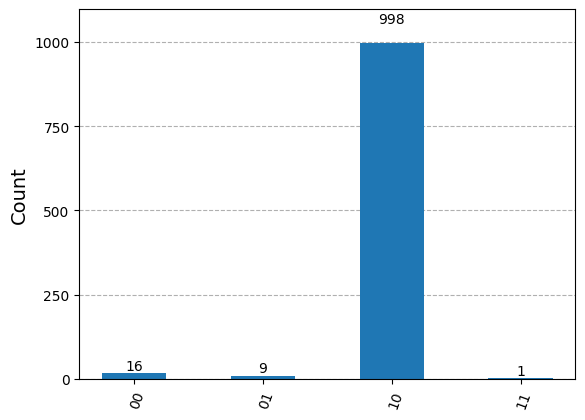


Encoded data qubit counts:
{'110': 1, '010': 4, '000': 982, '100': 31, '111': 6}


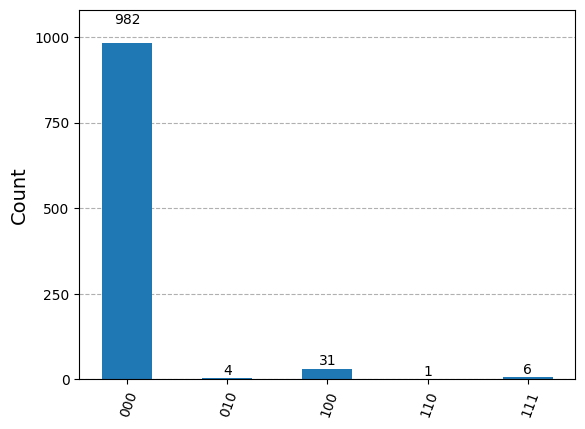


=== Check 17: Double bit-flip errors on q0 and q2, starting from |1> ===
Full counts:
{'11100': 6, '11111': 1, '01101': 3, '00000': 4, '11010': 12, '10011': 4, '00101': 5, '11110': 10, '01011': 5, '00111': 3, '11101': 5, '00011': 966}

Syndrome counts:
{'00': 10, '11': 979, '01': 13, '10': 22}


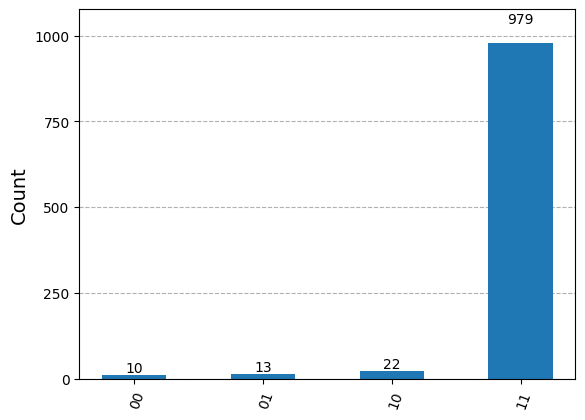


Encoded data qubit counts:
{'111': 22, '011': 3, '000': 970, '110': 12, '100': 4, '001': 8, '010': 5}


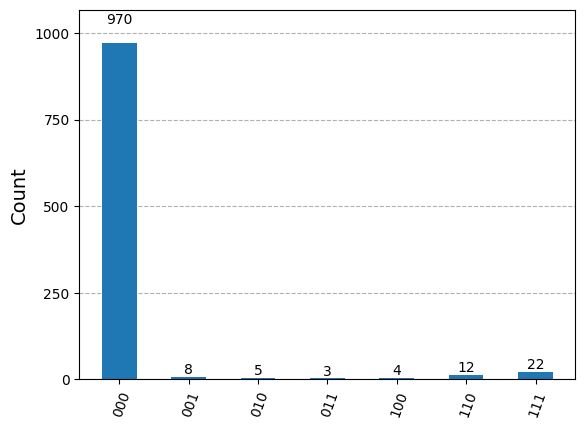


=== Check 18: Double bit-flip errors on q1 and q2, starting from |1> ===
Full counts:
{'10001': 3, '00101': 2, '01001': 1, '00000': 1, '00010': 8, '11110': 6, '11111': 1, '00100': 18, '00001': 984}

Syndrome counts:
{'01': 990, '00': 19, '10': 14, '11': 1}


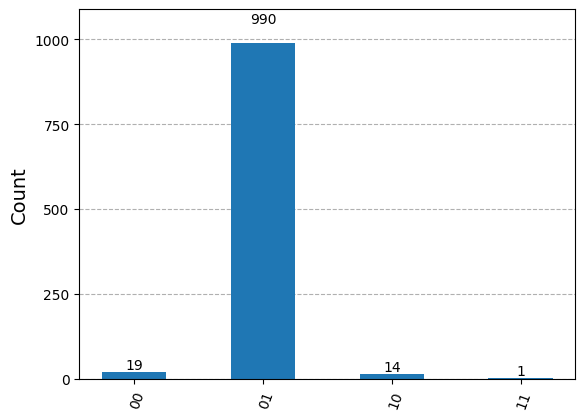


Encoded data qubit counts:
{'100': 3, '001': 20, '010': 1, '000': 993, '111': 7}


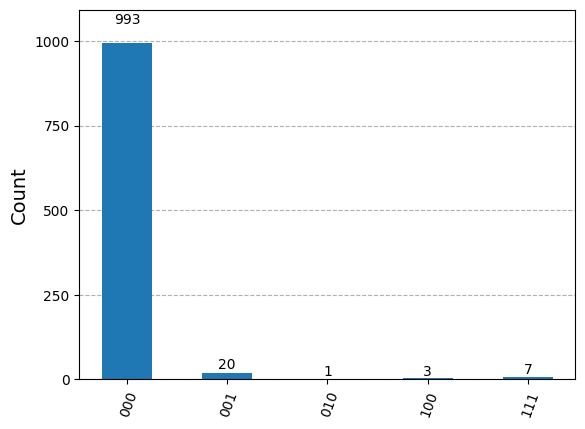

In [11]:
print("\n=== Check 16: Double bit-flip errors on q0 and q1, starting from |1> ===")
run_and_show(error_ops=[("x", 0), ("x", 1)], prepare="1")

print("\n=== Check 17: Double bit-flip errors on q0 and q2, starting from |1> ===")
run_and_show(error_ops=[("x", 0), ("x", 2)], prepare="1")

print("\n=== Check 18: Double bit-flip errors on q1 and q2, starting from |1> ===")
run_and_show(error_ops=[("x", 1), ("x", 2)], prepare="1")